> 🔎 **원본(HD 1920×1080) 버전** — 입력 `clips_hd`, 결과 `auto_D9_mouthing_hd.csv`. 240p 결과와 검출률 비교가 목적.

# D9_mouthing — 무라벨(라벨링 없이) 획득

입 뻐끔거림을 "입 영역의 0.7~3.0Hz 주기적 개폐 진동"으로 정의하고, 두 개의 상보적 1D 신호에서 주기성을 측정한다: (1) MediaPipe FaceMesh 입술 랜드마크로 만든 MAR(mouth aspect ratio) 시계열 — EAR(Soukupová & Čech)의 입 버전, (2) 입 ROI의 Farneback 광학흐름 평균 수직성분 — 저해상도/야간 IR로 랜드마크가 깨질 때를 대비한 대체 경로이며 NNS(비영양적 빨기) 논문들이 쓰는 신호와 동일 계열이다. 두 신호를 이동평균 하이패스로 detrend한 뒤 Welch PSD 대역파워비 × 피크 규칙성(1-IPI 변동계수)으로 점수화하고, 이마/머리 위 대조 ROI의 같은 대역 파워로 나눈 contrast를 곱해 몸 전체 흔들림·카메라 아티팩트를 억제한다. 수동 라벨 없이 점수 분포의 P95 + 게이트(contrast≥1.5, face_frac≥0.4, sound_frac<0.5로 울음 제외, 주피크 in-band)로 의사양성을 뽑는다. 합성 신호 검증에서 2Hz 뻐끔 0.88~0.92, 비주기 0.20, 하품 0.00, 0.3Hz 머리흔들림 0.002로 분리되었다.

In [1]:
# 설치 셀 — 처음 실행 후 protobuf/numpy 경고가 나오면: 런타임 → 세션 다시 시작 → 이어서 실행
!pip install -q mediapipe==0.10.14 av decord
!pip -q uninstall -y tensorflow  # mediapipe 0.10.14(protobuf4)와 TF(protobuf5) 충돌 방지 — 이 노트북은 TF 미사용

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.


In [2]:
# 공통 설정 — Drive 마운트 + 경로 + manifest
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import pandas as pd

BASE = Path('/content/drive/MyDrive/BabyMon/dataset')   # ← 업로드 위치
CLIPS = None
for cand in (BASE/'clips', BASE/'resized_2', BASE):
    if cand.is_dir() and next(cand.glob('*.mp4'), None):
        CLIPS = cand; break
assert CLIPS, 'mp4 폴더 없음 (clips/ 또는 resized_2/)'
assert (BASE/'manifest.csv').exists(), 'manifest.csv 를 BASE 에 업로드하세요'
WORK = Path('/content/work'); WORK.mkdir(exist_ok=True)
man = pd.read_csv(BASE/'manifest.csv')
print('clips:', CLIPS, len(list(CLIPS.glob("*.mp4"))), '개 / manifest:', len(man))

# ── HD(원본) 모드: clips_hd 를 우선 사용 ─────────────────────────
_hd = BASE/'clips_hd'
if _hd.is_dir() and next(_hd.glob('*.mp4'), None):
    CLIPS = _hd
    print('HD 모드: ', CLIPS, len(list(CLIPS.glob("*.mp4"))), '개 (1920x1080)')
else:
    raise SystemExit('clips_hd 없음 — D:\\carved\\dataset\\clips_hd 를 Drive 의 dataset/clips_hd 로 업로드하세요')

Mounted at /content/drive
clips: /content/drive/MyDrive/BabyMon/dataset/clips 24080 개 / manifest: 24080
HD 모드:  /content/drive/MyDrive/BabyMon/dataset/clips_hd 5395 개 (1920x1080)


## D9_mouthing — 입 뻐끔거림(배고픔 신호) 무라벨 획득

### 정의
뻐끔거림 = **입 영역이 0.7~3.0 Hz로 주기적으로 열리고 닫히는 진동**. (영아 non-nutritive sucking(NNS) 버스트는 대략 2 Hz, 루팅/뻐끔은 1~2.5 Hz. 15 fps → Nyquist 7.5 Hz 이므로 충분히 관측 가능)

### 신호 2개 (상보적)
1. **MAR (mouth aspect ratio)** — MediaPipe FaceMesh 입술 랜드마크에서 `(수직 3쌍 평균)/(입꼬리 폭)`. EAR(눈)의 입 버전이며 입꼬리 폭으로 나누므로 얼굴 크기·거리에 불변.
2. **입 ROI 광학흐름의 평균 수직성분** — Farneback flow의 `v_y` 평균. **랜드마크가 깨질 때(240x136 저해상도, 야간 IR, 옆으로 누운 자세)도 동작**하는 대체 경로이자, NNS 논문들이 실제로 쓰는 신호와 같은 계열.

### 점수화
- 이동평균 하이패스로 detrend → 자세 변화·**하품(1회 큰 개방)** 같은 저주파 제거
- Welch PSD **대역파워비** `P(0.7~3Hz)/P(>0.15Hz)` × **규칙성** `1 - IPI 변동계수`
- × **contrast gain** `c/(c+1)`, `c = 입ROI 대역파워 / 이마·머리위 대조ROI 대역파워`
  → 몸 전체 들썩임·카메라 흔들림처럼 **얼굴 전체가 같이 진동하는 아티팩트를 억제** (입만 움직여야 점수가 남음)
- 최종 `mouth_score ∈ [0,1]`

### 무라벨 임계값
점수 분포 **P95** + 게이트(`contrast≥1.5`, `face_frac≥0.4`, manifest의 `sound_frac<0.5`로 **울음(입 크게 벌림+큰 소리) 제외**, 주피크가 대역 내). 수동 라벨 없음.

### 합성 신호 사전검증 결과
| 케이스 | score |
|---|---|
| 2 Hz 뻐끔 (MAR) | 0.88 |
| 2 Hz 턱 움직임 (flow) | 0.92 |
| 비주기 자세변화 | 0.20 |
| 하품 1회 | 0.00 |
| 0.3 Hz 머리 흔들림 | 0.002 |

### 출처
- [A Video-based End-to-end Pipeline for Non-nutritive Sucking Action Recognition and Segmentation in Young Infants (MICCAI 2023)](https://arxiv.org/abs/2303.16867) — in-crib 베이비모니터 영상 + ROI 광학흐름
- [Subtle Signals: Video-based Detection of Infant Non-nutritive Sucking (CVIU 2024)](https://arxiv.org/abs/2310.16138) — 미세 빨기 신호 증폭/검출
- [공식 코드 (ostadabbas/NNS-Detection-and-Segmentation)](https://github.com/ostadabbas/NNS-Detection-and-Segmentation)
- [Real-Time Eye Blink Detection using Facial Landmarks (CVWW 2016)](https://www.semanticscholar.org/paper/Real-Time-Eye-Blink-Detection-using-Facial-Soukupov%C3%A1-Cech/4fa1ba3531219ca8c39d8749160faf1a877f2ced) — EAR 원 논문
- [Real-Time Driver Drowsiness Detection Using Facial Analysis (Sensors 2025)](https://www.mdpi.com/1424-8220/25/3/812) — MAR 정의

> 비용: T4 불필요(전부 CPU). 클립당 약 1.5~2.5초 → 1,000개 ≈ 30~45분.

In [3]:
!pip install -q mediapipe==0.10.14

import numpy as np, pandas as pd, cv2, json, time
from pathlib import Path
from decord import VideoReader, cpu
from scipy.signal import welch, find_peaks, detrend

FPS_ASSUME = 15.0
UPSCALE = 1  # HD 원본이라 업스케일 불필요           # 240x136 -> 720x408 (mediapipe 는 작은 얼굴에 매우 취약)
BAND       = (0.7, 3.0)  # 뻐끔/sucking 리듬 대역 [Hz] (NNS burst ~2Hz)
OUT_CSV    = BASE/'auto_D9_mouthing_hd.csv'

FACE = None
try:
    import mediapipe as mp
    # legacy solutions API: 모델이 패키지에 내장 -> 별도 다운로드 없이 오프라인 동작
    FACE = mp.solutions.face_mesh.FaceMesh(
        static_image_mode=False, max_num_faces=1, refine_landmarks=False,
        min_detection_confidence=0.2, min_tracking_confidence=0.2)
    print('FaceMesh OK, mediapipe', mp.__version__)
except Exception as e:
    # 버전에 따라 solutions API 가 제거될 수 있음 -> 광학흐름 전용 모드로 자동 강등
    print('[warn] FaceMesh 불가, optical-flow only:', e)

LIP_V = [(13, 14), (81, 178), (311, 402)]   # 안쪽 입술 수직 3쌍
LIP_H = (78, 308)                            # 안쪽 입꼬리 (스케일 정규화용)

FaceMesh OK, mediapipe 0.10.14


In [4]:
# ---- 신호 유틸 (합성 데이터로 검증 완료) ----
def _hp(x, fps, cut=0.5):
    """이동평균 차분 하이패스: 자세변화/서서히 벌어지는 하품 같은 저주파 제거"""
    x = np.asarray(x, float)
    w = max(3, int(round(fps/cut)) | 1)
    pad = np.pad(x, (w//2, w//2), mode='edge')
    return x - np.convolve(pad, np.ones(w)/w, mode='valid')[:len(x)]

def _fillnan(x):
    """랜드마크 결측 프레임 선형보간 (20% 결측까지 주파수 추정 안정 확인)"""
    x = np.asarray(x, float); m = np.isfinite(x)
    if m.sum() < 2: return np.zeros_like(x)
    return np.interp(np.arange(len(x)), np.flatnonzero(m), x[m])

def _band_stats(x, fps, band=BAND):
    """Welch PSD -> (대역파워비, 대역내 주피크 Hz, 대역 절대파워)"""
    x = np.asarray(x, float)
    if len(x) < 24 or not np.isfinite(x).all() or x.std() < 1e-9: return 0.0, 0.0, 0.0
    x = detrend(x)
    nper = int(min(len(x), max(32, fps*4)))
    f, p = welch(x, fs=fps, nperseg=nper)
    m = (f >= band[0]) & (f <= band[1])
    tot = p[f > 0.15].sum() + 1e-12          # DC/초저주파(자세변화) 제외
    if not m.any(): return 0.0, 0.0, 0.0
    return float(p[m].sum()/tot), float(f[m][np.argmax(p[m])]), float(p[m].sum())

def _peak_stats(x, fps, band=BAND):
    """주기적 개폐 -> (초당 피크수, 규칙성=1-IPI변동계수, 피크수)"""
    x = np.asarray(x, float)
    if len(x) < 24 or x.std() < 1e-9: return 0.0, 0.0, 0.0
    z = detrend(x); z = z/(z.std()+1e-9)
    pk, _ = find_peaks(z, prominence=0.6, distance=max(1, int(fps/band[1])))
    reg = 0.0
    if len(pk) >= 3:
        ipi = np.diff(pk)/fps
        reg = float(np.clip(1.0 - ipi.std()/(ipi.mean()+1e-9), 0, 1))
    return float(len(pk)/(len(x)/fps)), reg, float(len(pk))

In [5]:
# ---- 얼굴 랜드마크 / ROI 유틸 ----
def _landmarks(frame_rgb, W, H):
    if FACE is None: return None
    try:
        big = cv2.resize(frame_rgb, (W*UPSCALE, H*UPSCALE), interpolation=cv2.INTER_CUBIC)
        res = FACE.process(np.ascontiguousarray(big))
    except Exception:
        return None                      # 프레임 단위 실패는 결측으로 처리
    if not getattr(res, 'multi_face_landmarks', None): return None
    return res.multi_face_landmarks[0].landmark

def _mar(lm, W, H):
    """MAR = 입술 수직거리 3쌍 평균 / 입꼬리 폭 (EAR 의 입 버전)"""
    P = lambda i: np.array([lm[i].x*W, lm[i].y*H])
    hd = np.linalg.norm(P(LIP_H[0]) - P(LIP_H[1])) + 1e-6
    return float(np.mean([np.linalg.norm(P(a)-P(b)) for a, b in LIP_V])/hd)

def _lip_box(lm, W, H):
    idx = [i for p in LIP_V for i in p] + list(LIP_H)
    pts = np.array([[lm[i].x*W, lm[i].y*H] for i in idx])
    c = pts.mean(0); r = max(7.0, (pts.max(0)-pts.min(0)).max()*0.9)
    return np.array([c[0]-r, c[1]-r*0.8, c[0]+r, c[1]+r*0.8])

def _clipbox(b, W, H, dy=0.0):
    """프레임 경계로 클립. dy 는 박스 높이 배수만큼 상하 이동(대조 ROI 생성용)"""
    x0, y0, x1, y1 = map(float, b); h = y1-y0
    y0, y1 = y0+dy*h, y1+dy*h
    x0, x1 = np.clip([x0, x1], 0, W-1); y0, y1 = np.clip([y0, y1], 0, H-1)
    if x1-x0 < 6 or y1-y0 < 5: return None
    return tuple(int(v) for v in (x0, y0, x1, y1))

def _motion_box(gray, W, H):
    """랜드마크 실패(야간 IR 등) 대비: 시간축 표준편차 상위 픽셀 중심 = 움직이는 머리 부위"""
    sd = gray.astype(np.float32).std(0)
    ys, xs = np.where(sd >= np.percentile(sd, 98))
    if len(xs) < 10: return None
    return _clipbox([xs.mean()-14, ys.mean()-12, xs.mean()+14, ys.mean()+12], W, H)

def _flow_sig(gray, box, up=3):
    """ROI Farneback 광학흐름의 평균 수직성분 시계열 (NNS 파이프라인 flow 신호의 축약판)"""
    x0, y0, x1, y1 = box
    cr = [cv2.resize(g[y0:y1, x0:x1], None, fx=up, fy=up, interpolation=cv2.INTER_CUBIC) for g in gray]
    out = []
    for a, b in zip(cr[:-1], cr[1:]):
        try:
            fl = cv2.calcOpticalFlowFarneback(a, b, None, 0.5, 2, 9, 2, 5, 1.1, 0)
            out.append(float(fl[..., 1].mean()))
        except Exception:
            out.append(0.0)
    return np.array(out, float)

In [6]:
# ---- 클립 1개 처리 -> dict ----
COLS = ['file','ok','n_frames','fps','face_frac','roi_src','mar_bandratio','mar_fpeak','mar_rate',
        'mar_reg','mar_amp','flow_bandratio','flow_fpeak','flow_reg','ctrl_bandratio','contrast',
        'mouth_score','mar_json','flow_json']

def _blank(fn, note='na'):
    d = {c: 0.0 for c in COLS}
    d.update(file=fn, ok=0, roi_src=note, mar_json='', flow_json='')
    return d

def process_clip(fn, max_frames=128):
    r = _blank(fn)
    try:
        vr = VideoReader(str(CLIPS/fn), ctx=cpu(0))
        n = min(len(vr), max_frames)
        if n < 24: return _blank(fn, 'tooshort')      # 1.6s 미만이면 주기 추정 불가
        fr = vr.get_batch(list(range(n))).asnumpy()   # (n,H,W,3) RGB
        fps = vr.get_avg_fps()
        fps = float(fps) if fps and fps > 1 else FPS_ASSUME
    except Exception:
        return _blank(fn, 'readfail')
    H, W = fr.shape[1], fr.shape[2]
    gray = np.stack([cv2.cvtColor(f, cv2.COLOR_RGB2GRAY) for f in fr])
    mar, boxes = [], []
    for f in fr:
        lm = _landmarks(f, W, H)
        if lm is None: mar.append(np.nan); continue
        mar.append(_mar(lm, W, H)); boxes.append(_lip_box(lm, W, H))
    mar = np.array(mar, float)
    r.update(file=fn, n_frames=n, fps=round(fps, 2),
             face_frac=round(float(np.isfinite(mar).mean()), 3))
    if len(boxes) >= 0.4*n:
        box, r['roi_src'] = _clipbox(np.median(np.stack(boxes), 0), W, H), 'lips'
    else:
        box, r['roi_src'] = _motion_box(gray, W, H), 'motion'
    if r['face_frac'] > 0.4:                          # 경로1: MAR 시계열
        m = _hp(_fillnan(mar), fps)
        br, fp, _ = _band_stats(m, fps); rate, reg, _ = _peak_stats(m, fps)
        r.update(mar_bandratio=round(br, 4), mar_fpeak=round(fp, 3), mar_rate=round(rate, 3),
                 mar_reg=round(reg, 3), mar_amp=round(float(np.nanstd(mar)), 4),
                 mar_json=json.dumps([round(float(v), 3) for v in np.nan_to_num(mar, nan=-1.0)]))
    if box is None: return r
    fs = _hp(_flow_sig(gray, box), fps)               # 경로2: 입 ROI 광학흐름
    fbr, ffp, fbp = _band_stats(fs, fps); _, freg, _ = _peak_stats(fs, fps)
    cbr, cbp = 0.0, 0.0
    ctrl = _clipbox(box, W, H, dy=-1.6)               # 이마/머리 위 대조 ROI = 전신 흔들림 성분
    if ctrl is not None:
        cbr, _, cbp = _band_stats(_hp(_flow_sig(gray, ctrl), fps), fps)
    contrast = float(fbp/(cbp+1e-9))                  # 입만 진동해야 커짐
    per = max(r['mar_bandratio'], fbr); reg2 = max(r['mar_reg'], freg)
    r.update(ok=1, flow_bandratio=round(fbr, 4), flow_fpeak=round(ffp, 3), flow_reg=round(freg, 3),
             ctrl_bandratio=round(cbr, 4), contrast=round(min(contrast, 99.0), 3),
             mouth_score=round(per*reg2*(contrast/(contrast+1.0)), 4),
             flow_json=json.dumps([round(float(v), 4) for v in fs]))
    return r

In [7]:
# ---- 배치 루프 (증분 저장, 중단 후 재실행 안전) ----
N_CLIPS = 1000
samp = man.sample(n=min(N_CLIPS, len(man)), random_state=0)['file'].tolist()
done = set(pd.read_csv(OUT_CSV)['file']) if OUT_CSV.exists() else set()
todo = [f for f in samp if f not in done]
print(f'표본 {len(samp)} / 완료 {len(done)} / 남음 {len(todo)}')

def _flush(buf):
    if not buf: return
    d = pd.DataFrame(buf)
    if OUT_CSV.exists():                      # 검증셀이 y_D9 컬럼을 추가해도 정렬 유지
        d = d.reindex(columns=list(pd.read_csv(OUT_CSV, nrows=0).columns))
    d.to_csv(OUT_CSV, mode='a', header=not OUT_CSV.exists(), index=False)

buf, t0 = [], time.time()
for i, fn in enumerate(todo, 1):
    try:
        buf.append(process_clip(fn))
    except Exception as e:
        buf.append(_blank(fn, f'err:{type(e).__name__}'))
    if i % 25 == 0: _flush(buf); buf = []
    if i % 50 == 0:
        el = time.time() - t0
        print(f'{i}/{len(todo)}  {el/i:.2f}s/clip  ETA {(len(todo)-i)*el/i/60:.1f}min')
_flush(buf)
print('저장 완료:', OUT_CSV)

표본 1000 / 완료 0 / 남음 1000


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


50/1000  6.32s/clip  ETA 100.0min


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


100/1000  5.97s/clip  ETA 89.6min


...

900/1000  6.17s/clip  ETA 10.3min


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


950/1000  6.16s/clip  ETA 5.1min


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


1000/1000  6.17s/clip  ETA 0.0min
저장 완료: /content/drive/MyDrive/BabyMon/dataset/auto_D9_mouthing_hd.csv


### 의사라벨 규칙과 한계

`y_D9 = 1` 조건 (전부 무라벨 기준):
- `mouth_score ≥ P95` — 절대 임계값이 아니라 **분포 기반**(데이터셋이 바뀌어도 이동)
- `contrast ≥ 1.5` — 입 ROI가 이마 ROI보다 대역 파워 1.5배 이상 → 몸 전체 들썩임 배제
- `face_frac ≥ 0.4` — 랜드마크 근거가 충분한 클립만 양성 (flow 단독 근거는 점수만 남기고 양성 제외)
- `sound_frac < 0.5` — **울음 배제**. 울음은 입을 크게·지속적으로 벌리고 소리가 큼. 뻐끔은 조용하고 진폭이 작음
- `mar_fpeak ∈ [0.7, 3.0]` — 주피크가 실제로 대역 안

**한계 (다음 단계에서 확인 필요)**
1. MediaPipe FaceMesh는 성인 얼굴 위주 학습 → **영아 + 야간 IR + 옆으로 누운 자세에서 `face_frac`이 낮게 나올 수 있음**. 아래 검증 셀의 `roi_src` 분포로 `lips` vs `motion` 비율을 반드시 확인할 것. `lips` 비율이 30% 미만이면 flow 단독 경로를 주신호로 승격하고 `face_frac` 게이트를 낮춰야 한다.
2. **뻐끔 vs 빨기(공갈젖꼭지/손가락)** 는 이 신호만으로 구분되지 않는다 (NNS 논문들도 같은 신호를 씀). 배고픔 신호로 쓰려면 손/공갈 검출을 별도 라벨로 결합하는 것이 정석.
3. 주기적 아티팩트(선풍기, 모빌, IR LED 플리커)가 입 ROI에 겹치면 오양성 → `contrast`와 `mean_ydif` 산점도로 점검.
4. P95는 유병률 가정(5%)이다. 검증 셀에서 극단 사례를 눈으로 본 뒤 조정하라.

ok=986/1000  THR(P95)=0.220  positive=1
         count      mean     max
roi_src                         
lips        30  0.025970  0.3629
motion     956  0.057347  0.6449


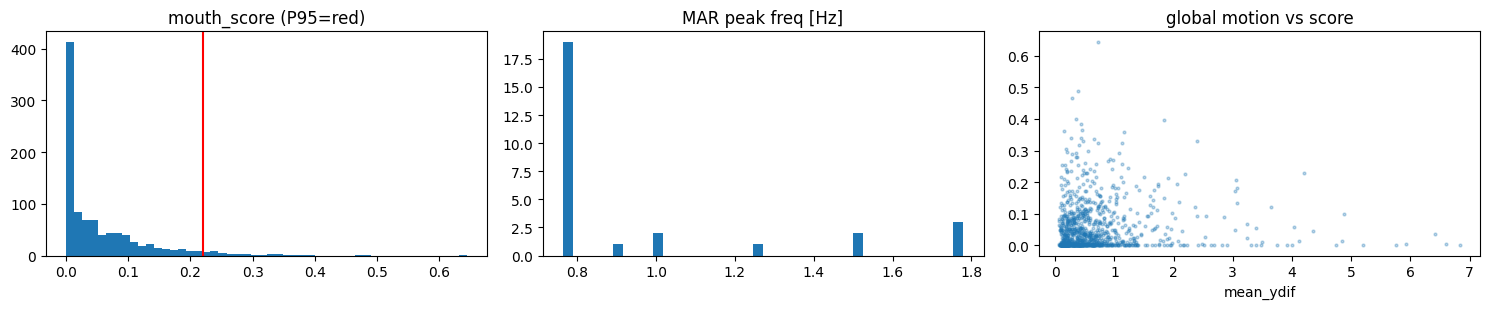

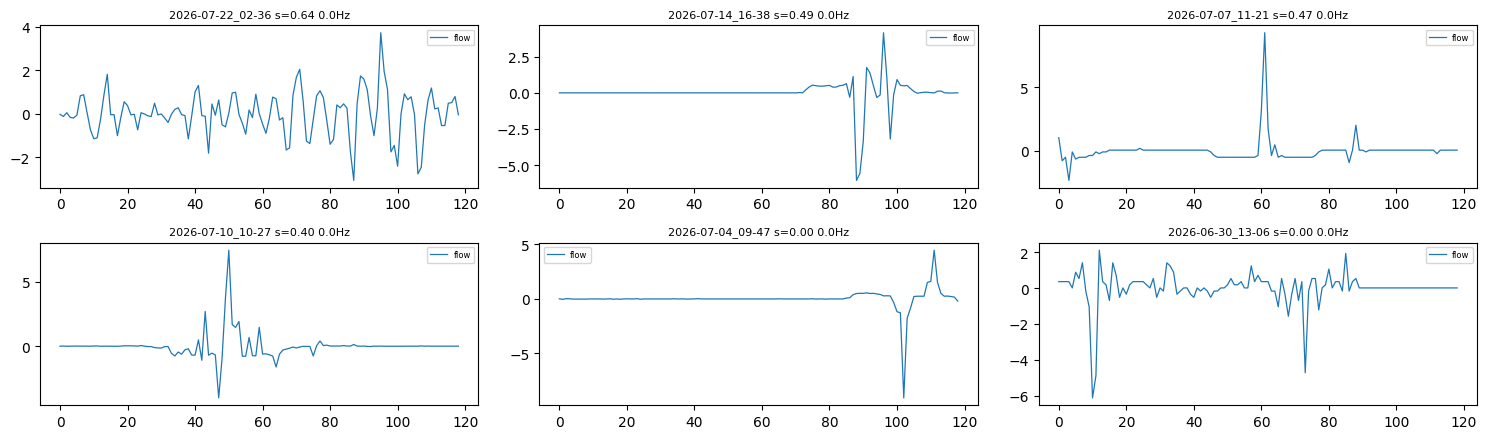

                        file  mouth_score  mar_fpeak  mar_reg  flow_reg  contrast  sound_frac  y_D9
960  2026-07-22_02-36-40.mp4       0.6449        0.0      0.0     0.823      99.0       0.075     0
133  2026-07-14_16-38-42.mp4       0.4883        0.0      0.0     0.891      99.0       0.025     0
621  2026-07-07_11-21-29.mp4       0.4656        0.0      0.0     0.844      99.0       0.000     0
316  2026-07-10_10-27-22.mp4       0.3985        0.0      0.0     0.742      99.0       0.000     0
2    2026-07-04_09-47-40.mp4       0.0000        0.0      0.0     0.000      99.0       0.200     0
8    2026-06-30_13-06-43.mp4       0.0000        0.0      0.0     0.198       0.0       0.075     0


In [8]:
# ---- 검증: 분포 + 극단 사례 ----
import matplotlib.pyplot as plt

def _sig(v, nanneg=False):
    if not isinstance(v, str) or not v: return np.array([])
    s = np.array(json.loads(v), float)
    if nanneg: s[s < 0] = np.nan            # MAR 결측은 -1 로 인코딩됨
    return s

df = pd.read_csv(OUT_CSV).drop_duplicates('file', keep='last').drop(columns=['y_D9'], errors='ignore')
d = df[df.ok == 1].merge(man[['file','mean_ydif','sound_frac']], on='file', how='left')
THR = float(d.mouth_score.quantile(0.95))
d['y_D9'] = ((d.mouth_score >= THR) & (d.contrast >= 1.5) & (d.face_frac >= 0.4)
             & (d.sound_frac.fillna(0) < 0.5) & d.mar_fpeak.between(*BAND)).astype(int)
print(f'ok={len(d)}/{len(df)}  THR(P95)={THR:.3f}  positive={int(d.y_D9.sum())}')
print(d.groupby('roi_src')['mouth_score'].agg(['count','mean','max']))   # lips vs motion 비율 확인
df.merge(d[['file','y_D9']], on='file', how='left').to_csv(OUT_CSV, index=False)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
ax[0].hist(d.mouth_score, bins=50); ax[0].axvline(THR, c='r'); ax[0].set_title('mouth_score (P95=red)')
ax[1].hist(d.loc[d.mar_bandratio > 0, 'mar_fpeak'], bins=40); ax[1].set_title('MAR peak freq [Hz]')
ax[2].scatter(d.mean_ydif, d.mouth_score, s=4, alpha=.3)
ax[2].set_xlabel('mean_ydif'); ax[2].set_title('global motion vs score')
plt.tight_layout(); plt.show()

ext = pd.concat([d.nlargest(4, 'mouth_score'), d.nsmallest(2, 'mouth_score')])
fig, ax = plt.subplots(2, 3, figsize=(15, 4.5))
for a, (_, r) in zip(ax.ravel(), ext.iterrows()):
    for nm, col, nn in (('MAR', 'mar_json', True), ('flow', 'flow_json', False)):
        s = _sig(r[col], nn)
        if s.size: a.plot((s-np.nanmean(s))/(np.nanstd(s)+1e-9), lw=.9, label=nm)
    a.legend(fontsize=6)
    a.set_title(f'{r.file[:16]} s={r.mouth_score:.2f} {r.mar_fpeak:.1f}Hz', fontsize=8)
plt.tight_layout(); plt.show()
print(ext[['file','mouth_score','mar_fpeak','mar_reg','flow_reg','contrast','sound_frac','y_D9']].to_string())